In [1]:
# Cell 1 — Install & Import Library
!pip install -q tensorflowjs scikit-learn seaborn

import os, sys, json, time, shutil, random, subprocess, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.55.1 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.5.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab

2026-07-30 23:17:32.064259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785453452.090860      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785453452.099854      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785453452.121121      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785453452.121156      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785453452.121159      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Cell 2 — Konfigurasi (path, hyperparameter, daftar eksperimen)

SEED = 42

# Kaggle
DATASET_DIR = Path("/kaggle/input/datasets/khmdsy/dataset-kelontong/dataset-kelontong-v2")
OUTPUT_ROOT = Path("/kaggle/working/Research_POS")

# Colab — uncomment jika pakai Colab:
# DATASET_DIR = Path("/content/DATASET")
# OUTPUT_ROOT = Path("/content/Research_POS")

IMAGE_SIZE    = (224, 224)
IMG_HEIGHT, IMG_WIDTH = IMAGE_SIZE
CHANNELS      = 3
NUM_CLASSES_EXPECTED = 24
BATCH_SIZE    = 32
MAX_EPOCHS    = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTHING = 0.1

EARLY_STOPPING_PATIENCE = 7
REDUCE_LR_PATIENCE      = 3
REDUCE_LR_FACTOR        = 0.2
MIN_LR                  = 1e-7
FINE_TUNE_LAST_N        = 15

TRAIN_SIZE      = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE       = 0.15

USE_CACHE    = True
CACHE_IN_RAM = True
CACHE_DIR    = Path("/kaggle/working/research_pos_cache")
if not CACHE_IN_RAM:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

USE_CUTMIX  = False
CUTMIX_ALPHA = 1.0

AUTOTUNE = tf.data.AUTOTUNE

# Hanya 2 eksperimen
EXPERIMENTS = {
    "E1_MobileNetV3": {
        "backbone":   "MobileNetV3Large",
        "attention":  None,
    },
    "E2_MobileNetV3_CBAM": {
        "backbone":   "MobileNetV3Large",
        "attention":  "CBAM",
    },
}

for d in ["DATA_REPORT", "LOG", "COMPARISON", "FINAL_MODEL", "EXPERIMENT"]:
    (OUTPUT_ROOT / d).mkdir(parents=True, exist_ok=True)

print("Output:", OUTPUT_ROOT)
print("Experiments:", list(EXPERIMENTS.keys()))

Output: /kaggle/working/Research_POS
Experiments: ['E1_MobileNetV3', 'E2_MobileNetV3_CBAM']


In [3]:
# Cell 3 — Utility functions (folder, JSON, ukuran file, parameter count)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return Path(path)

def save_json(data, path):
    path = Path(path)
    ensure_dir(path.parent)
    with open(path, "w") as f:
        json.dump(data, f, indent=4, default=str)

def save_text(text, path):
    path = Path(path)
    ensure_dir(path.parent)
    path.write_text(str(text), encoding="utf-8")

def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def file_size_mb(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size / (1024**2)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / (1024**2)
    return 0.0

def count_parameters(model):
    trainable     = int(np.sum([np.prod(v.shape) for v in model.trainable_variables]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_variables]))
    return {
        "parameters":             trainable + non_trainable,
        "trainable_parameters":   trainable,
        "non_trainable_parameters": non_trainable,
    }

def get_last_4d_layer(model):
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer
        except Exception:
            pass
    return None

In [4]:
# Cell 4 — Kumpulkan file gambar, buat label, simpan class mapping & class.json

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_image_files(dataset_dir):
    dataset_dir = Path(dataset_dir)
    records = []
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in VALID_EXTENSIONS:
                records.append({"filepath": str(img_path), "class_name": class_dir.name})
    df = pd.DataFrame(records)
    if df.empty:
        raise FileNotFoundError(f"Tidak ada gambar di {dataset_dir}")
    class_names    = sorted(df["class_name"].unique())
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    df["label"]    = df["class_name"].map(class_to_index)
    return df, class_names, class_to_index

image_df, CLASS_NAMES, CLASS_TO_INDEX = collect_image_files(DATASET_DIR)
NUM_CLASSES = len(CLASS_NAMES)

# class_mapping.json — index ke nama kelas
save_json(
    {"class_names": CLASS_NAMES, "class_to_index": CLASS_TO_INDEX,
     "num_classes": NUM_CLASSES, "num_images": len(image_df)},
    OUTPUT_ROOT / "DATA_REPORT" / "class_mapping.json",
)

# class.json — format inference TFJS: {"0": "nama_kelas", ...}
class_json = {str(idx): name for name, idx in CLASS_TO_INDEX.items()}
save_json(class_json, OUTPUT_ROOT / "DATA_REPORT" / "class.json")

print(f"Kelas   : {NUM_CLASSES}")
print(f"Gambar  : {len(image_df)}")
if NUM_CLASSES != NUM_CLASSES_EXPECTED:
    print(f"PERINGATAN: ekspektasi {NUM_CLASSES_EXPECTED} kelas, aktual {NUM_CLASSES}")
print(CLASS_NAMES)

Kelas   : 24
Gambar  : 4800
['amo-sparkling-milk-strawberry-200ml', 'cleo-mineral-220ml', 'emeron-alovera', 'frisian-flag-fullcream-225ml', 'frisian-flag-strawberry-225ml', 'gemez-enaak-22g', 'giv-hijab-rose-water', 'indomie-goreng', 'indomie-goreng-jumbo', 'masako-ayam', 'mie-sedaap-ayam-bawang', 'mie-sedaap-laksa', 'milku-coklat-200ml', 'milku-original-200ml', 'pepsodent-merah-72g', 'sarimi-ayam-bawang', 'siiplah-mineral-220ml', 'soffell-kuning13lt', 'soffell-unggu-13lt', 'soklin-lantai-freesia-rose-52ml', 'soklin-liquid-korean-camellia-22g', 'soklin-royale-starry-night', 'ultramilk-fullcream-200ml', 'vica-mineral-600ml']


In [5]:
# Cell 5 — Stratified split 70/15/15

train_df, tmp_df = train_test_split(
    image_df, test_size=(VALIDATION_SIZE + TEST_SIZE),
    stratify=image_df["label"], random_state=SEED,
)
relative_test = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
validation_df, test_df = train_test_split(
    tmp_df, test_size=relative_test,
    stratify=tmp_df["label"], random_state=SEED,
)

train_df      = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df       = test_df.reset_index(drop=True)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(validation_df)}")
print(f"Test       : {len(test_df)}")

pd.concat([
    train_df.assign(split="train"),
    validation_df.assign(split="validation"),
    test_df.assign(split="test"),
], ignore_index=True).to_csv(OUTPUT_ROOT / "DATA_REPORT" / "dataset_split.csv", index=False)

Train      : 3360
Validation : 720
Test       : 720


In [6]:
# Cell 6 — Decode, resize (center-crop), augmentasi, CutMix, cache, prefetch

def decode_and_resize(path, label):
    """Resize sisi terpendek ≥ target lalu center-crop — menghindari distorsi dan black bar."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    shape  = tf.shape(image)
    h, w   = tf.cast(shape[0], tf.float32), tf.cast(shape[1], tf.float32)
    scale  = tf.maximum(IMG_HEIGHT / h, IMG_WIDTH / w)
    new_h  = tf.cast(tf.round(h * scale), tf.int32)
    new_w  = tf.cast(tf.round(w * scale), tf.int32)

    image  = tf.image.resize(image, [new_h, new_w],
                             method=tf.image.ResizeMethod.BILINEAR, antialias=True)
    image  = tf.image.resize_with_crop_or_pad(image, IMG_HEIGHT, IMG_WIDTH)
    image  = tf.cast(image, tf.float32)
    label  = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08, fill_mode="reflect"),
    layers.RandomZoom((-0.10, 0.10), (-0.10, 0.10), fill_mode="reflect"),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10, value_range=(0.0, 255.0)),
], name="data_augmentation")

def cutmix_batch(images, labels, alpha=1.0):
    batch_size      = tf.shape(images)[0]
    idx             = tf.random.shuffle(tf.range(batch_size))
    shuf_images     = tf.gather(images, idx)
    shuf_labels     = tf.gather(labels, idx)
    lam             = tf.cast(tf.compat.v1.distributions.Beta(alpha, alpha).sample(), tf.float32)
    cut_ratio       = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(IMG_HEIGHT, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(IMG_WIDTH,  tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, IMG_HEIGHT, dtype=tf.int32)
    cx = tf.random.uniform([], 0, IMG_WIDTH,  dtype=tf.int32)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, IMG_HEIGHT)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, IMG_HEIGHT)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, IMG_WIDTH)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, IMG_WIDTH)
    mask = tf.pad(tf.ones((y2 - y1, x2 - x1)),
                  [[y1, IMG_HEIGHT - y2], [x1, IMG_WIDTH - x2]])
    mask = tf.reshape(mask, [IMG_HEIGHT, IMG_WIDTH, 1])
    mixed_images = images * (1 - mask) + shuf_images * mask
    lam_adj = 1.0 - tf.cast((y2 - y1) * (x2 - x1), tf.float32) / tf.cast(IMG_HEIGHT * IMG_WIDTH, tf.float32)
    mixed_labels = lam_adj * labels + (1 - lam_adj) * shuf_labels
    return mixed_images, mixed_labels

def create_dataset(df, split_name, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"].astype(str).values, df["label"].astype(np.int32).values)
    )
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if USE_CACHE:
        ds = ds.cache() if CACHE_IN_RAM else ds.cache(str(CACHE_DIR / f"{split_name}.cache"))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    if training and USE_CUTMIX:
        ds = ds.map(lambda x, y: cutmix_batch(x, y, CUTMIX_ALPHA), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds      = create_dataset(train_df,      "train",      training=True)
validation_ds = create_dataset(validation_df, "validation", training=False)
test_ds       = create_dataset(test_df,       "test",       training=False)

print("Dataset siap. CutMix:", USE_CUTMIX, "| Cache:", USE_CACHE)

I0000 00:00:1785453473.992619      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785453473.999260      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Dataset siap. CutMix: False | Cache: True


In [7]:
# Cell 7 — Implementasi CBAMLayer (satu-satunya attention yang dipakai)

class CBAMLayer(layers.Layer):
    """Convolutional Block Attention Module — channel + spatial attention."""

    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        hidden   = max(channels // self.reduction_ratio, 1)
        self.ch_dense1   = layers.Dense(hidden,   activation="relu", use_bias=True)
        self.ch_dense2   = layers.Dense(channels, activation=None,   use_bias=True)
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, padding="same",
                                          activation="sigmoid", use_bias=False)
        super().build(input_shape)

    def call(self, inputs):
        avg_p = tf.reduce_mean(inputs, axis=[1, 2])
        max_p = tf.reduce_max(inputs,  axis=[1, 2])
        ch_att = tf.nn.sigmoid(
            self.ch_dense2(self.ch_dense1(avg_p)) +
            self.ch_dense2(self.ch_dense1(max_p))
        )
        ch_att = tf.reshape(ch_att, [-1, 1, 1, tf.shape(ch_att)[-1]])
        x = inputs * ch_att
        sp_feat = tf.concat([
            tf.reduce_mean(x, axis=-1, keepdims=True),
            tf.reduce_max(x,  axis=-1, keepdims=True),
        ], axis=-1)
        return x * self.spatial_conv(sp_feat)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction_ratio": self.reduction_ratio})
        return cfg

In [8]:
# Cell 8 — Build MobileNetV3Large ± CBAM, partial fine-tune, compile AdamW

def build_backbone(backbone_name, input_tensor):
    if backbone_name == "MobileNetV3Large":
        return tf.keras.applications.MobileNetV3Large(
            input_tensor=input_tensor,
            include_top=False,
            weights="imagenet",
            include_preprocessing=True,   # PENTING: preprocessing built-in
        )
    raise ValueError(f"Backbone tidak dikenal: {backbone_name}")

def set_partial_trainable(backbone, last_n=15):
    total = len(backbone.layers)
    for i, layer in enumerate(backbone.layers):
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = (i >= total - last_n)

def build_model(backbone_name, attention_name=None):
    inputs  = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), dtype=tf.float32)
    backbone = build_backbone(backbone_name, inputs)
    set_partial_trainable(backbone, last_n=FINE_TUNE_LAST_N)
    x = backbone.output
    if attention_name == "CBAM":
        x = CBAMLayer(reduction_ratio=8, name="cbam_attention")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="predictions")(x)
    return keras.Model(inputs=inputs, outputs=outputs,
                       name=f"{backbone_name}_{attention_name or 'Baseline'}")

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy")],
    )
    return model

In [9]:
# Cell 9 — EarlyStopping, ReduceLR, ModelCheckpoint, dan fungsi train_experiment

class ResearchLogger(keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path   = Path(log_path)
        self.start_time = None

    def _write(self, msg):
        with open(self.log_path, "a") as f:
            f.write(f"[{now_string()}] {msg}\n")

    def on_train_begin(self, logs=None):
        self.start_time = time.perf_counter()
        self._write("Start Training")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self._write(f"Epoch {epoch+1} | loss={logs.get('loss'):.4f} | "
                    f"acc={logs.get('accuracy'):.4f} | val_loss={logs.get('val_loss'):.4f} | "
                    f"val_acc={logs.get('val_accuracy'):.4f}")

    def on_train_end(self, logs=None):
        self._write(f"Done — {time.perf_counter() - self.start_time:.1f}s")

def create_experiment_dirs(name):
    exp_dir = OUTPUT_ROOT / "EXPERIMENT" / name
    for sub in ["checkpoint", "history", "model", "saved_model",
                "tensorflowjs", "tflite", "plots", "confusion_matrix",
                "prediction", "report", "weights", "log"]:
        ensure_dir(exp_dir / sub)
    return exp_dir

def create_callbacks(exp_dir):
    return [
        keras.callbacks.ModelCheckpoint(
            str(exp_dir / "checkpoint" / "best.weights.h5"),
            monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE, min_lr=MIN_LR, verbose=1),
        ResearchLogger(exp_dir / "log" / "training.txt"),
    ]

def train_experiment(exp_name, exp_config):
    exp_dir = create_experiment_dirs(exp_name)
    model   = compile_model(build_model(exp_config["backbone"], exp_config["attention"]))

    print(f"\n{'='*70}\n{exp_name}\n{'='*70}")
    param_info = count_parameters(model)
    display(pd.DataFrame(param_info.items(), columns=["metric", "value"]))

    t0 = time.perf_counter()
    history = model.fit(
        train_ds, validation_data=validation_ds,
        epochs=MAX_EPOCHS, callbacks=create_callbacks(exp_dir), verbose=1,
    )
    train_time = time.perf_counter() - t0

    hist_df   = pd.DataFrame(history.history)
    best_epoch = int(hist_df["val_loss"].idxmin() + 1)
    hist_df.to_csv(exp_dir / "history" / "history.csv", index=False)

    # Plot training curve
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist_df["accuracy"],     label="Train");  axes[0].plot(hist_df["val_accuracy"], label="Val")
    axes[0].set_title(f"{exp_name} — Accuracy"); axes[0].legend()
    axes[1].plot(hist_df["loss"],         label="Train");  axes[1].plot(hist_df["val_loss"],     label="Val")
    axes[1].set_title(f"{exp_name} — Loss");     axes[1].legend()
    plt.tight_layout()
    plt.savefig(exp_dir / "plots" / "training_history.png", dpi=200)
    plt.show()

    model.save(exp_dir / "model" / "model.keras")
    model.save_weights(exp_dir / "weights" / "final.weights.h5")

    training_info = {
        **param_info,
        "training_time_seconds": train_time,
        "best_epoch": best_epoch,
        "best_val_accuracy": float(hist_df.loc[best_epoch - 1, "val_accuracy"]),
        "best_val_loss":     float(hist_df.loc[best_epoch - 1, "val_loss"]),
    }
    save_json(training_info, exp_dir / "report" / "training_info.json")

    return {"model": model, "history": hist_df,
            "experiment_dir": exp_dir, "training_info": training_info}

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

E1_MobileNetV3


,metric,value
0,parameters,3019418
1,trainable_parameters,816264
2,non_trainable_parameters,2203154


Epoch 1/50


I0000 00:00:1785453507.912036      82 service.cc:152] XLA service 0x79885c113270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785453507.912079      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1785453507.912084      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1785453510.039115      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-07-30 23:18:40.726959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 23:18:40.865683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 23:18:41.214484: E external/local_xl

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.0714 - loss: 3.5739 - top5_accuracy: 0.2842

2026-07-30 23:19:24.177385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 23:19:24.311769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 23:19:24.631029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 23:19:24.768869: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 2.45849, saving model to /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/checkpoint/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/checkpoint/best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 90s 404ms/step - accuracy: 0.1170 - loss: 3.1950 - top5_accuracy: 0.3926 - val_accuracy: 0.4236 - val_loss: 2.4585 - val_top5_accuracy: 0.8000 - learning_rate: 1.0000e-04
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3675 - loss: 2.3904 - top5_accuracy: 0.7242
Epoch 2: val_loss improved from 2.45849 to 1.34021, saving model to /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/checkpoint/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/checkpoint/best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 194ms/step - accuracy: 0.4470 - loss: 2.1511 - top5_accuracy: 0.7991 - val_accuracy: 0.8264 - val_loss: 1.3402 - val_top5_a

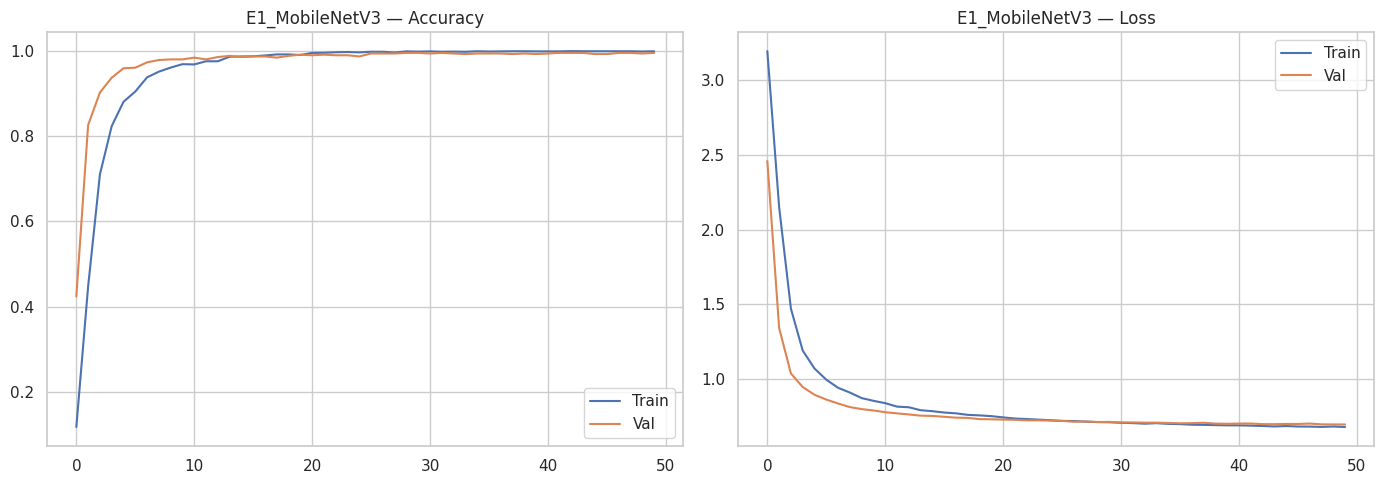


E2_MobileNetV3_CBAM


,metric,value
0,parameters,3250996
1,trainable_parameters,1047842
2,non_trainable_parameters,2203154


Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.0649 - loss: 3.1694 - top5_accuracy: 0.2882
Epoch 1: val_loss improved from None to 2.42605, saving model to /kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/checkpoint/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/checkpoint/best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 307ms/step - accuracy: 0.1199 - loss: 3.0257 - top5_accuracy: 0.4077 - val_accuracy: 0.4361 - val_loss: 2.4261 - val_top5_accuracy: 0.8417 - learning_rate: 1.0000e-04
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4530 - loss: 2.1529 - top5_accuracy: 0.8153
Epoch 2: val_loss improved from 2.42605 to 1.13555, saving model to /kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/checkpoint/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/checkpoint/best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━

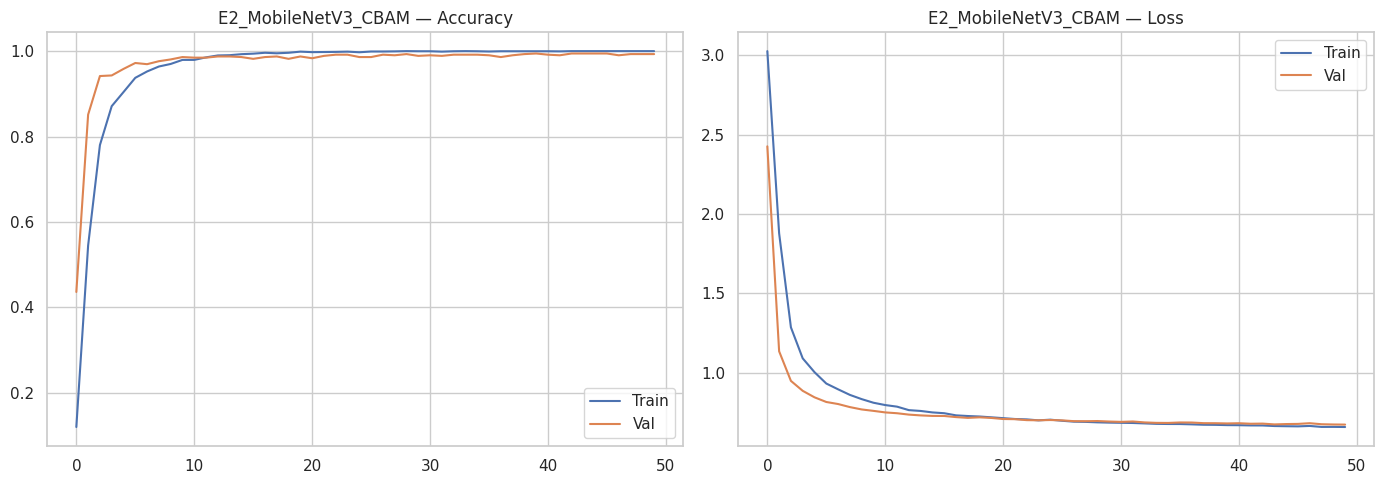


Seluruh eksperimen selesai.


In [10]:
# Cell 10 — Training E1_MobileNetV3 dan E2_MobileNetV3_CBAM

RESULTS = {}

for exp_name, exp_config in EXPERIMENTS.items():
    set_global_seed(SEED)
    RESULTS[exp_name] = train_experiment(exp_name, exp_config)

print("\nSeluruh eksperimen selesai.")

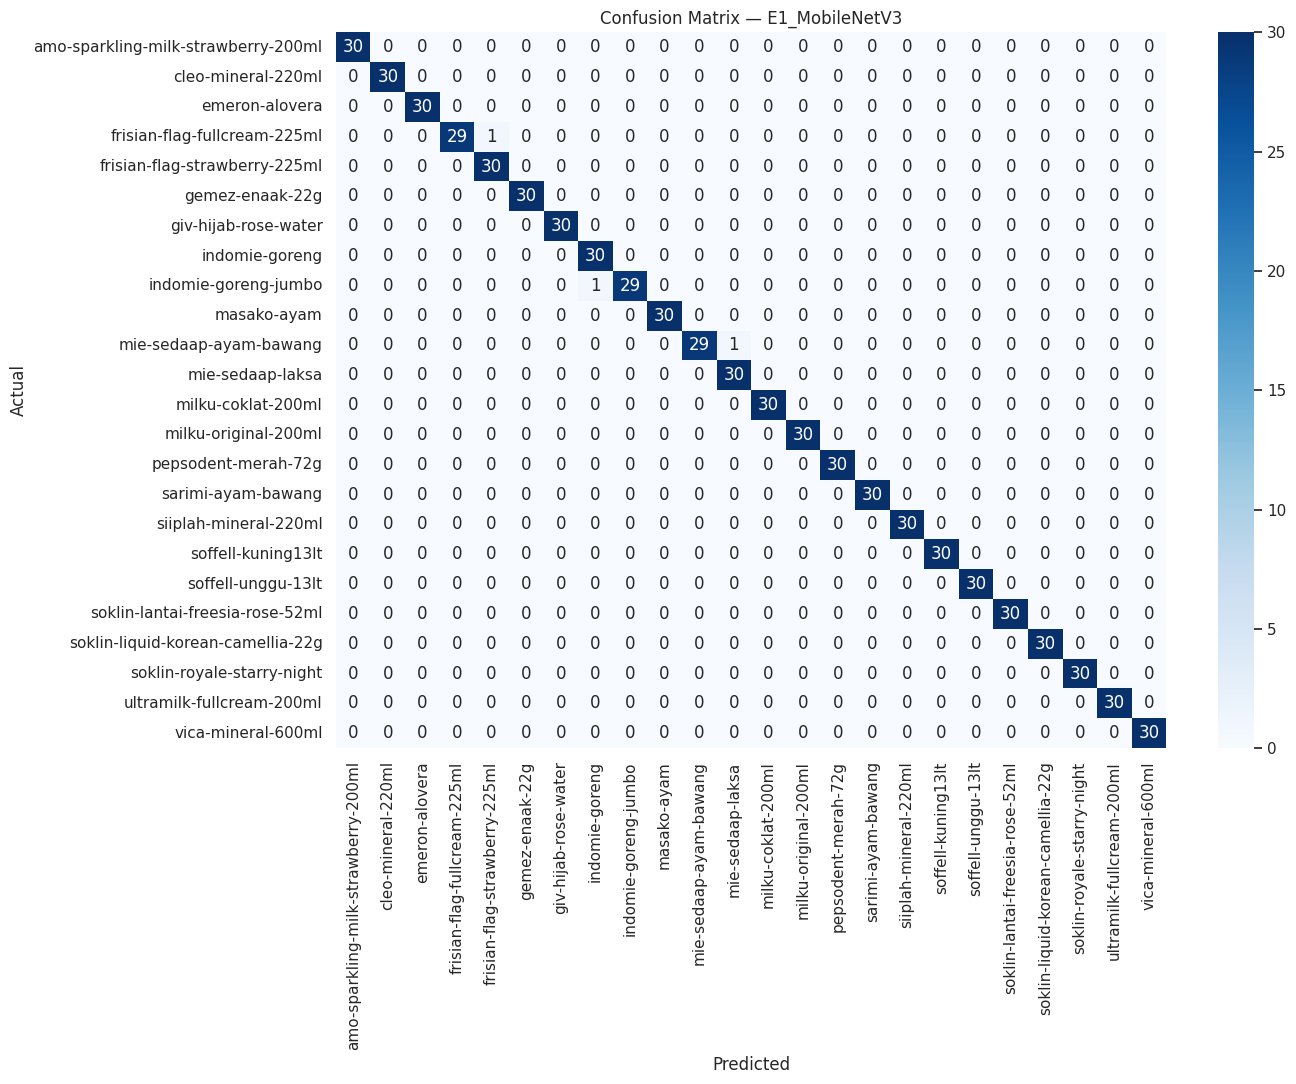

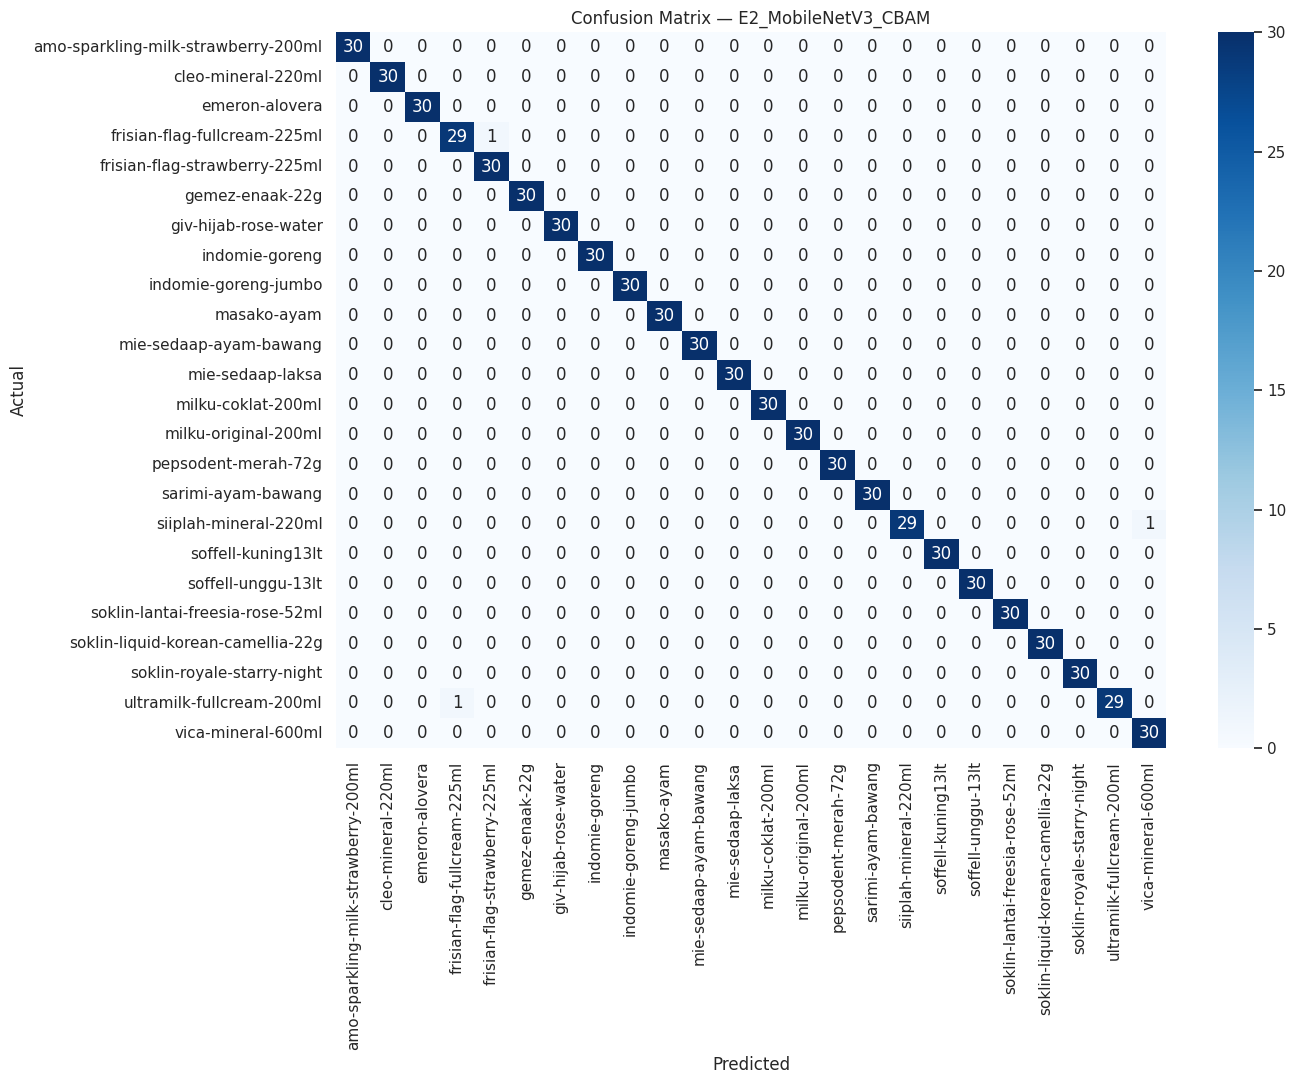


Evaluasi selesai.


In [11]:
# Cell 11 — Prediksi test set, hitung metrik, confusion matrix, classification report

def predict_dataset(model, dataset):
    y_true, y_prob = [], []
    for images, labels in dataset:
        y_prob.append(model.predict(images, verbose=0))
        y_true.append(labels.numpy() if hasattr(labels, "numpy") else np.asarray(labels))
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    return np.argmax(y_true, 1), np.argmax(y_prob, 1), y_true, y_prob

def measure_inference(model, dataset, n_warmup=3):
    batch_images = next(iter(dataset))[0]
    for _ in range(n_warmup):
        model(batch_images, training=False)
    t0, total = time.perf_counter(), 0
    for images, _ in dataset:
        model(images, training=False); total += images.shape[0]
    elapsed = time.perf_counter() - t0
    return {"inference_time_per_image_ms": elapsed / total * 1000, "fps": total / elapsed}

def evaluate_experiment(exp_name, result):
    model   = result["model"]
    exp_dir = result["experiment_dir"]

    y_true_ids, y_pred_ids, y_true_oh, y_prob = predict_dataset(model, test_ds)

    acc  = accuracy_score(y_true_ids, y_pred_ids)
    prec = precision_score(y_true_ids, y_pred_ids, average="macro", zero_division=0)
    rec  = recall_score(y_true_ids, y_pred_ids, average="macro", zero_division=0)
    f1   = f1_score(y_true_ids, y_pred_ids, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_true_oh, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan

    inf_info = measure_inference(model, test_ds)
    metrics  = {
        "experiment":       exp_name,
        "accuracy":         acc,
        "precision_macro":  prec,
        "recall_macro":     rec,
        "f1_macro":         f1,
        "auc_macro_ovr":    auc,
        **inf_info,
        **count_parameters(model),
        "training_time_seconds": result["training_info"]["training_time_seconds"],
        "best_epoch":            result["training_info"]["best_epoch"],
        "best_val_accuracy":     result["training_info"]["best_val_accuracy"],
    }
    pd.DataFrame([metrics]).to_csv(exp_dir / "metrics.csv", index=False)

    # Classification Report
    report = classification_report(
        y_true_ids, y_pred_ids, target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(exp_dir / "report" / "classification_report.csv")

    # Confusion Matrix
    cm = confusion_matrix(y_true_ids, y_pred_ids, labels=np.arange(NUM_CLASSES))
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {exp_name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=90); plt.tight_layout()
    plt.savefig(exp_dir / "confusion_matrix" / "confusion_matrix.png", dpi=200)
    plt.show()

    result.update({
        "metrics": metrics,
        "y_true_ids": y_true_ids, "y_pred_ids": y_pred_ids,
        "y_true_onehot": y_true_oh, "y_prob": y_prob,
    })
    return result

for exp_name in RESULTS:
    RESULTS[exp_name] = evaluate_experiment(exp_name, RESULTS[exp_name])

print("\nEvaluasi selesai.")

In [12]:
# Cell 12 — Export setiap eksperimen ke SavedModel, TFLite, dan TFJS

def export_saved_model(model, out_dir):
    out_dir = Path(out_dir)
    if out_dir.exists():
        shutil.rmtree(out_dir)
    try:
        model.export(str(out_dir))
    except Exception:
        tf.saved_model.save(model, str(out_dir))
    return out_dir

def export_tflite(model, out_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = []
    tflite_bytes = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_bytes)
    return out_path

def export_tensorflowjs(saved_model_dir, tfjs_dir):
    tfjs_dir = Path(tfjs_dir)
    if tfjs_dir.exists():
        shutil.rmtree(tfjs_dir)
    ensure_dir(tfjs_dir)
    cmd = [sys.executable, "-m", "tensorflowjs.converters.converter",
           "--input_format=tf_saved_model", str(saved_model_dir), str(tfjs_dir)]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        res = subprocess.run(
            ["tensorflowjs_converter", "--input_format=tf_saved_model",
             str(saved_model_dir), str(tfjs_dir)],
            capture_output=True, text=True,
        )
    save_text(res.stdout + "\n" + res.stderr, tfjs_dir / "conversion_log.txt")
    if res.returncode == 0:
        print(f"TFJS OK → {tfjs_dir}")
    else:
        print(f"TFJS GAGAL: {res.stderr[:300]}")
    return tfjs_dir

def export_all_formats(exp_name, result):
    model   = result["model"]
    exp_dir = result["experiment_dir"]

    saved_model_dir = exp_dir / "saved_model" / "model"
    tflite_path     = exp_dir / "tflite" / "model.tflite"
    tfjs_dir        = exp_dir / "tensorflowjs"

    export_saved_model(model, saved_model_dir)
    export_tflite(model, tflite_path)
    export_tensorflowjs(saved_model_dir, tfjs_dir)

    export_info = {
        "saved_model_size_mb":     file_size_mb(saved_model_dir),
        "tflite_size_mb":          file_size_mb(tflite_path),
        "tensorflowjs_size_mb":    file_size_mb(tfjs_dir),
    }
    save_json(export_info, exp_dir / "report" / "export_info.json")
    result["export_info"] = export_info
    return result

for exp_name in RESULTS:
    print(f"\nExporting {exp_name}...")
    RESULTS[exp_name] = export_all_formats(exp_name, RESULTS[exp_name])

print("\nSemua export selesai.")


Exporting E1_MobileNetV3...
INFO:tensorflow:Assets written to: /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/saved_model/model/assets


INFO:tensorflow:Assets written to: /kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/saved_model/model/assets


Saved artifact at '/kaggle/working/Research_POS/EXPERIMENT/E1_MobileNetV3/saved_model/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  133632396593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397152656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397152080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397151696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397154000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397154384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153616: TensorSp

INFO:tensorflow:Assets written to: /tmp/tmpko2mu4hj/assets


Saved artifact at '/tmp/tmpko2mu4hj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  133632396593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397152656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397152080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397151696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397154000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397154384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133632397153616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13363239715

...

Saved artifact at '/kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/saved_model/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_212')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  133630616712400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037621840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037621648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037623760: T

INFO:tensorflow:Assets written to: /tmp/tmpd3so8pf0/assets


Saved artifact at '/tmp/tmpd3so8pf0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_212')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  133630616712400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037621840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037621648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037622032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037623760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133627037

W0000 00:00:1785455732.395364      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1785455732.395402      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TFJS OK → /kaggle/working/Research_POS/EXPERIMENT/E2_MobileNetV3_CBAM/tensorflowjs

Semua export selesai.


In [13]:
# Cell 13 — Buat tabel perbandingan 2 model, pilih yang terbaik berdasarkan accuracy → f1 → inference

rows = []
for exp_name, result in RESULTS.items():
    row = result["metrics"].copy()
    ei  = result.get("export_info", {})
    row.update({
        "model_size_mb_keras":        file_size_mb(result["experiment_dir"] / "model" / "model.keras"),
        "model_size_mb_tflite":       ei.get("tflite_size_mb", np.nan),
        "model_size_mb_tensorflowjs": ei.get("tensorflowjs_size_mb", np.nan),
    })
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(OUTPUT_ROOT / "COMPARISON" / "comparison_table.csv", index=False)

ranking_df = comparison_df.sort_values(
    by=["accuracy", "f1_macro", "inference_time_per_image_ms"],
    ascending=[False, False, True],
).reset_index(drop=True)
ranking_df["rank"] = np.arange(1, len(ranking_df) + 1)
ranking_df.to_csv(OUTPUT_ROOT / "COMPARISON" / "ranking.csv", index=False)

best_experiment_name = ranking_df.iloc[0]["experiment"]

print(f"\n{'='*60}")
print(f"Model terbaik: {best_experiment_name}")
print(f"{'='*60}")
display(ranking_df[["rank", "experiment", "accuracy", "f1_macro",
                     "auc_macro_ovr", "inference_time_per_image_ms",
                     "model_size_mb_tflite", "model_size_mb_tensorflowjs"]])


Model terbaik: E2_MobileNetV3_CBAM


,rank,experiment,accuracy,f1_macro,auc_macro_ovr,inference_time_per_image_ms,model_size_mb_tflite,model_size_mb_tensorflowjs
0,1,E2_MobileNetV3_CBAM,0.995833,0.995833,0.999996,7.390683,12.310402,13.372057
1,2,E1_MobileNetV3,0.995833,0.995832,0.999976,7.188179,11.424202,11.594501


In [14]:
# Cell 14 — Salin model terbaik (TFJS + TFLite + Keras) ke folder FINAL_MODEL beserta class.json

best_result  = RESULTS[best_experiment_name]
FINAL_DIR    = OUTPUT_ROOT / "FINAL_MODEL"

if FINAL_DIR.exists():
    shutil.rmtree(FINAL_DIR)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

for folder in ["model", "saved_model", "tensorflowjs", "tflite", "weights", "report"]:
    src = best_result["experiment_dir"] / folder
    if src.exists():
        shutil.copytree(src, FINAL_DIR / folder)

shutil.copy(best_result["experiment_dir"] / "metrics.csv", FINAL_DIR / "metrics.csv")

# Salin class.json ke dalam folder TFJS agar siap dipakai langsung di web
shutil.copy(OUTPUT_ROOT / "DATA_REPORT" / "class.json",
            FINAL_DIR / "tensorflowjs" / "class.json")

save_json({
    "best_experiment":  best_experiment_name,
    "selection_rule":   ["accuracy desc", "f1_macro desc", "inference_time_per_image_ms asc"],
    "accuracy":         best_result["metrics"]["accuracy"],
    "f1_macro":         best_result["metrics"]["f1_macro"],
}, FINAL_DIR / "best_model_info.json")

print(f"FINAL_MODEL siap di: {FINAL_DIR}")
print(f"Isi FINAL_MODEL/tensorflowjs:")
for f in sorted((FINAL_DIR / "tensorflowjs").iterdir()):
    print(f"  {f.name}  ({file_size_mb(f):.2f} MB)")

FINAL_MODEL siap di: /kaggle/working/Research_POS/FINAL_MODEL
Isi FINAL_MODEL/tensorflowjs:
  class.json  (0.00 MB)
  conversion_log.txt  (0.00 MB)
  group1-shard1of4.bin  (4.00 MB)
  group1-shard2of4.bin  (4.00 MB)
  group1-shard3of4.bin  (4.00 MB)
  group1-shard4of4.bin  (1.16 MB)
  model.json  (0.20 MB)


In [15]:
# Cell 16 — Ringkasan akurasi evaluasi kedua model dalam DataFrame

metrics_cols = [
    "experiment",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "auc_macro_ovr",
    "top5_accuracy",
    "inference_time_per_image_ms",
    "fps",
    "parameters",
    "best_epoch",
    "best_val_accuracy",
    "training_time_seconds",
]

eval_rows = []
for exp_name, result in RESULTS.items():
    m = result["metrics"]
    eval_rows.append({col: m.get(col, np.nan) for col in metrics_cols})

eval_df = pd.DataFrame(eval_rows)

# Format angka biar rapi
format_map = {
    "accuracy":                    "{:.4f}",
    "precision_macro":             "{:.4f}",
    "recall_macro":                "{:.4f}",
    "f1_macro":                    "{:.4f}",
    "auc_macro_ovr":               "{:.4f}",
    "top5_accuracy":               "{:.4f}",
    "inference_time_per_image_ms": "{:.4f}",
    "fps":                         "{:.2f}",
    "best_val_accuracy":           "{:.4f}",
    "training_time_seconds":       "{:.1f}",
}

eval_display = eval_df.copy()
for col, fmt in format_map.items():
    if col in eval_display.columns:
        eval_display[col] = eval_display[col].apply(lambda x: fmt.format(x) if pd.notna(x) else "-")

display(eval_display)

# Highlight model terbaik
best = eval_df.loc[eval_df["accuracy"].idxmax(), "experiment"]
best_acc = eval_df["accuracy"].max()
print(f"\nModel terbaik : {best}")
print(f"Accuracy      : {best_acc:.4f} ({best_acc*100:.2f}%)")

,experiment,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,top5_accuracy,inference_time_per_image_ms,fps,parameters,best_epoch,best_val_accuracy,training_time_seconds
0,E1_MobileNetV3,0.9958,0.9960,0.9958,0.9958,1.0000,-,7.1882,139.12,3019418,50,0.9958,1086.1
1,E2_MobileNetV3_CBAM,0.9958,0.9959,0.9958,0.9958,1.0000,-,7.3907,135.31,3250996,50,0.9931,1055.9



Model terbaik : E1_MobileNetV3
Accuracy      : 0.9958 (99.58%)


In [16]:
# Cell 17 — ZIP isi TFJS best model (model.json + *.bin + class.json), nama ZIP = nama model

import os
from IPython.display import FileLink, display as ipy_display

TFJS_DIR = FINAL_DIR / "tensorflowjs"
ZIP_PATH = str(OUTPUT_ROOT / f"{best_experiment_name}.zip")

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# Hanya ambil file relevan saja, exclude conversion_log.txt
include_files = (
    list(TFJS_DIR.glob("model.json")) +
    list(TFJS_DIR.glob("*.bin")) +
    [TFJS_DIR / "class.json"]
)

# Pastikan class.json ada
if not (TFJS_DIR / "class.json").exists():
    shutil.copy(OUTPUT_ROOT / "DATA_REPORT" / "class.json", TFJS_DIR / "class.json")

file_list = " ".join(f'"{f.name}"' for f in include_files if f.exists())
os.system(f'cd "{TFJS_DIR}" && zip -q "{ZIP_PATH}" {file_list}')

size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"ZIP     : {best_experiment_name}.zip")
print(f"Ukuran  : {size_mb:.2f} MB")
print(f"Isi ZIP :")
for f in include_files:
    if f.exists():
        print(f"  ✓ {f.name}  ({file_size_mb(f):.3f} MB)")

ipy_display(FileLink(ZIP_PATH))

ZIP     : E2_MobileNetV3_CBAM.zip
Ukuran  : 12.26 MB
Isi ZIP :
  ✓ model.json  (0.204 MB)
  ✓ group1-shard3of4.bin  (4.000 MB)
  ✓ group1-shard2of4.bin  (4.000 MB)
  ✓ group1-shard1of4.bin  (4.000 MB)
  ✓ group1-shard4of4.bin  (1.165 MB)
  ✓ class.json  (0.001 MB)


/kaggle/working/Research_POS/E2_MobileNetV3_CBAM.zip